In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
], dtype=float)

y = np.array([
    35, 40, 48, 55, 63,
    69, 76, 82, 89, 95
], dtype=float)

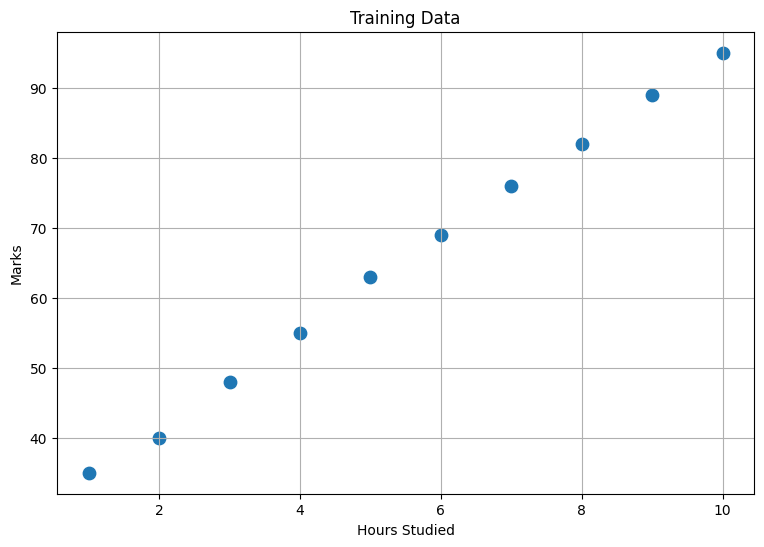

In [2]:
# visualize the data
plt.figure(figsize=(9, 6))

plt.scatter(X, y, s=80)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Training Data")

plt.grid(True)
plt.show()

In [5]:
# start with a terrible line
b0 = 0
b1 = 0
# prediction = 0 + 0 × hours
learning_rate = 0.01
epochs = 1000


In [6]:
# gradient descent from scrtch
loss_history = []

n = len(X)

for epoch in range(epochs):

    # Predictions
    y_pred = b0 + b1 * X

    # Errors
    error = y_pred - y

    # MSE loss
    loss = np.mean(error ** 2)

    loss_history.append(loss)

    # Gradients
    db0 = (2 / n) * np.sum(error)
    db1 = (2 / n) * np.sum(error * X)

    # Update parameters
    b0 = b0 - learning_rate * db0
    b1 = b1 - learning_rate * db1

print("Learned intercept:", b0)
print("Learned slope:", b1)

Learned intercept: 27.409190887847657
Learned slope: 6.856136036146345


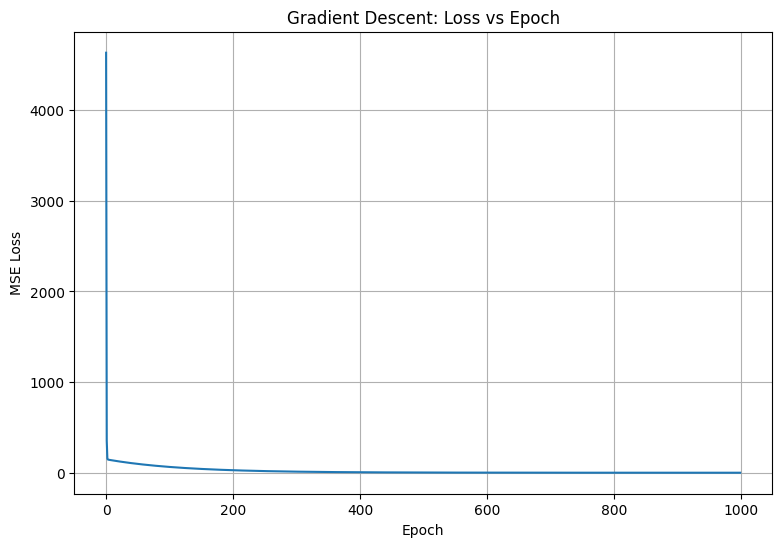

In [7]:
plt.figure(figsize=(9, 6))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent: Loss vs Epoch")

plt.grid(True)
plt.show()

In [10]:
# learning k doran kaisey change hota ha
b0 = 0
b1 = 0

learning_rate = 0.01

snapshots = []

n = len(X)

for epoch in range(1000):

    y_pred = b0 + b1 * X

    error = y_pred - y

    loss = np.mean(error ** 2)

    db0 = (2 / n) * np.sum(error)
    db1 = (2 / n) * np.sum(error * X)

    b0 -= learning_rate * db0
    b1 -= learning_rate * db1

    if epoch in [0, 1, 5, 20, 100, 999]:
        snapshots.append((epoch, b0, b1))

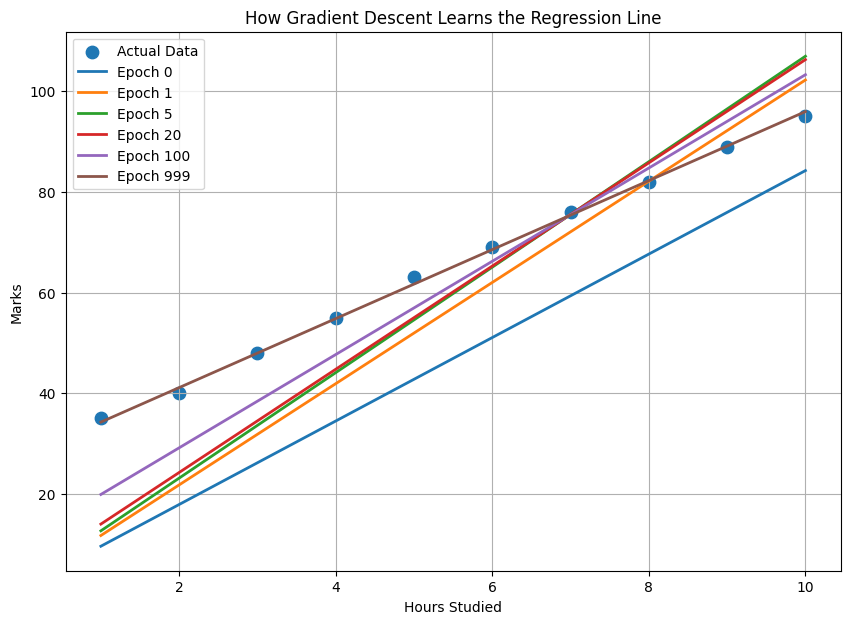

In [11]:
#  now plot htis graph
plt.figure(figsize=(10, 7))

plt.scatter(X, y, s=80, label="Actual Data")

x_line = np.linspace(1, 10, 100)

for epoch, b0_snapshot, b1_snapshot in snapshots:

    y_line = b0_snapshot + b1_snapshot * x_line

    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        label=f"Epoch {epoch}"
    )

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("How Gradient Descent Learns the Regression Line")

plt.legend()
plt.grid(True)
plt.show()

In [12]:
# now lets see the relation with the learning rate
learning_rates = [
    0.001,
    0.01,
    0.05
]

In [16]:
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)

# Standardize X
X_scaled = (X - np.mean(X)) / np.std(X)

n = len(X_scaled)

learning_rates = [0.001, 0.01, 0.05, 0.1]

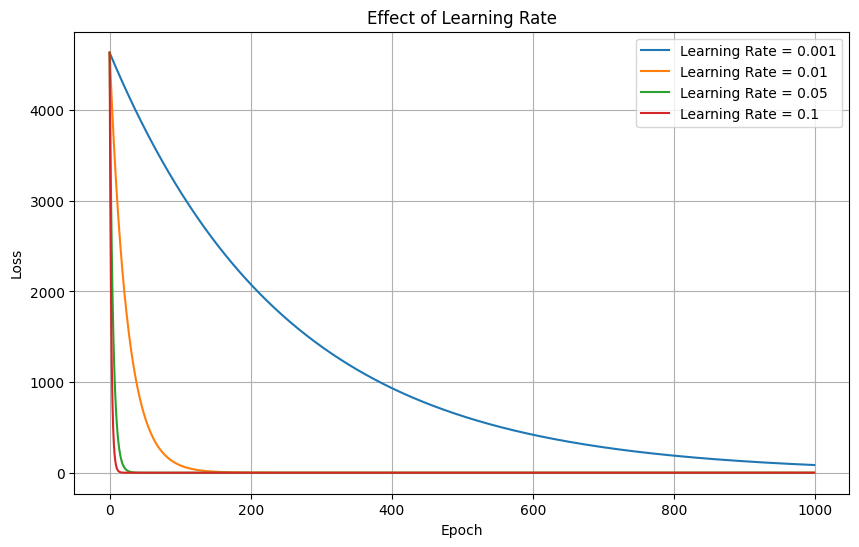

In [17]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    b0 = 0
    b1 = 0

    losses = []

    for epoch in range(1000):

        y_pred = b0 + b1 * X_scaled

        error = y_pred - y

        loss = np.mean(error ** 2)
        losses.append(loss)

        db0 = (2 / n) * np.sum(error)
        db1 = (2 / n) * np.sum(error * X_scaled)

        b0 -= lr * db0
        b1 -= lr * db1

    plt.plot(
        losses,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
# three types of the gradient descent
# batch gradient descent


In [19]:
# Suppose dataset mein:

# 1000 samples

# Batch Gradient Descent ek parameter update se pehle poore 1000 samples ko use karta hai.

# 1000 samples
#     ↓
# calculate gradients
#     ↓
# update parameters

# Then next iteration.

# Advantage

# Gradient relatively stable hota hai.

# Disadvantage

# Large dataset mein expensive ho sakta hai.

In [20]:
# Stochastic Gradient Descent

# SGD mein ek update ke liye one sample use hota hai.

# Sample 1
#    ↓
# update

# Sample 2
#    ↓
# update

# Sample 3
#    ↓
# update

# Isliye parameters bohat frequently update hote hain.

# Advantage

# Fast updates.

# Large datasets mein useful ho sakta hai.

# Disadvantage

# Updates noisy hote hain.

# Loss graph smooth nahi hota.

In [21]:
# Mini-Batch Gradient Descent

# Ye dono ke beech ka approach hai.

# Suppose:

# 1000 samples
# batch size = 32

# Then:

# 32 samples
#    ↓
# update

# 32 samples
#    ↓
# update

# 32 samples
#    ↓
# update

# Ye modern ML mein extremely common idea hai.

# Simple mental model:

# Batch       → ALL samples
# SGD         → 1 sample
# Mini-Batch  → small group

# That's it.

In [23]:
# SGDRegressor
# same data set
from sklearn.linear_model import SGDRegressor

X_2d = X.reshape(-1, 1)

sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

sgd_model.fit(X_2d, y)

SGDRegressor(learning_rate='constant', random_state=42)

In [24]:
# prediction
predictions = sgd_model.predict(X_2d)

print(predictions)

[33.6188975  40.57577813 47.53265875 54.48953938 61.44642001 68.40330063
 75.36018126 82.31706188 89.27394251 96.23082313]


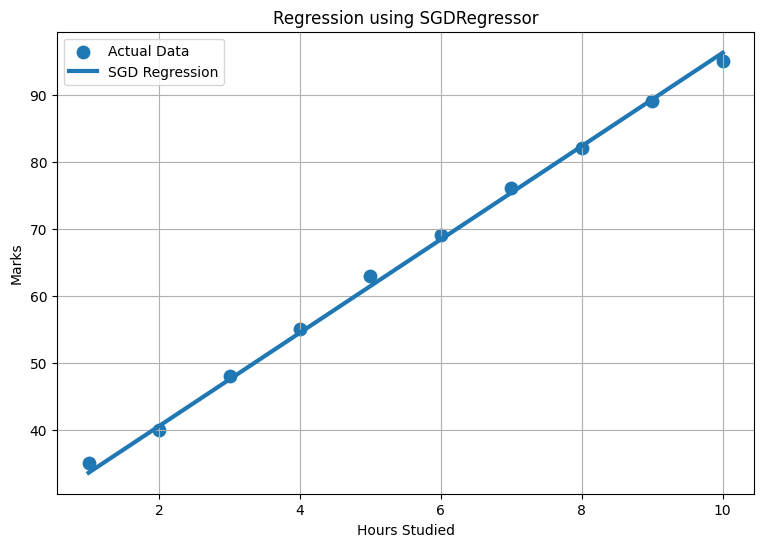

In [26]:
# graph
plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=80,
    label="Actual Data"
)

plt.plot(
    X,
    predictions,
    linewidth=3,
    label="SGD Regression"
)

plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Regression using SGDRegressor")

plt.legend()
plt.grid(True)

plt.show()